This notebook evaluates the results from XGBoost, including global and local feature importance

In [23]:
# =========================================
# Global Imports
# =========================================
import joblib
from joblib import dump
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# Preprocessing
# =========================================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

from sklearn.experimental import enable_iterative_imputer  # noqa: F401 (enables IterativeImputer)
from sklearn.impute import IterativeImputer, SimpleImputer

# =========================================
# Models
# =========================================
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# =========================================
# Model Selection / CV
# =========================================
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    TimeSeriesSplit,
    train_test_split
)

# =========================================
# Metrics
# =========================================
from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix,
    fbeta_score,
    make_scorer,
    precision_recall_curve,
    average_precision_score,
    roc_curve
)

# =========================================
# Pipeline
# =========================================
from sklearn.pipeline import Pipeline

# =========================================
# Feature importance
# =========================================
import shap

from sklearn.inspection import permutation_importance
import os
import xgboost as xgb


In [5]:
train_df = pd.read_pickle("../data/modeling/train_df.pkl")
test_df  = pd.read_pickle("../data/modeling/test_df.pkl")

target_col = "default_flag"

X_train = train_df.drop(columns=target_col)
y_train = train_df[target_col]

X_test = test_df.drop(columns=target_col)
y_test = test_df[target_col]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

xgb_preprocessor = joblib.load("../data/modeling/xg_preprocessor.pkl")
print("Loaded XGB preprocessor")

X_train_xgb_full_array = xgb_preprocessor.fit_transform(X_train)
xgb_feature_names_full = xgb_preprocessor.get_feature_names_out()

X_train_xgb_full = pd.DataFrame(
    data=X_train_xgb_full_array,
    columns=xgb_feature_names_full,
    index=X_train.index,
)

X_test_xgb_full_array = xgb_preprocessor.transform(X_test)

X_test_xgb_full = pd.DataFrame(
    data=X_test_xgb_full_array,
    columns=xgb_feature_names_full,
    index=X_test.index,
)

print("=== FULL XGB Preprocessing Complete ===")
print("Train shape:", X_train_xgb_full.shape)
print("Test shape :", X_test_xgb_full.shape)


X_train: (433620, 97)
y_train: (433620,)
Loaded XGB preprocessor
=== FULL XGB Preprocessing Complete ===
Train shape: (433620, 1077)
Test shape : (47191, 1077)


In [15]:

f2_scorer = make_scorer(fbeta_score, beta=2)

In [38]:
xgb_best = joblib.load("../results/XG/xgb_seed42_model.joblib")

# XGB predicted probabilities
y_scores_xgb = xgb_best.predict_proba(X_test_xgb_full)[:, 1]

# Precision-recall + AUC-PR (average precision)
prec_xgb, rec_xgb, thr_xgb = precision_recall_curve(y_test, y_scores_xgb)
auc_pr_xgb = average_precision_score(y_test, y_scores_xgb)


<Figure size 640x480 with 0 Axes>

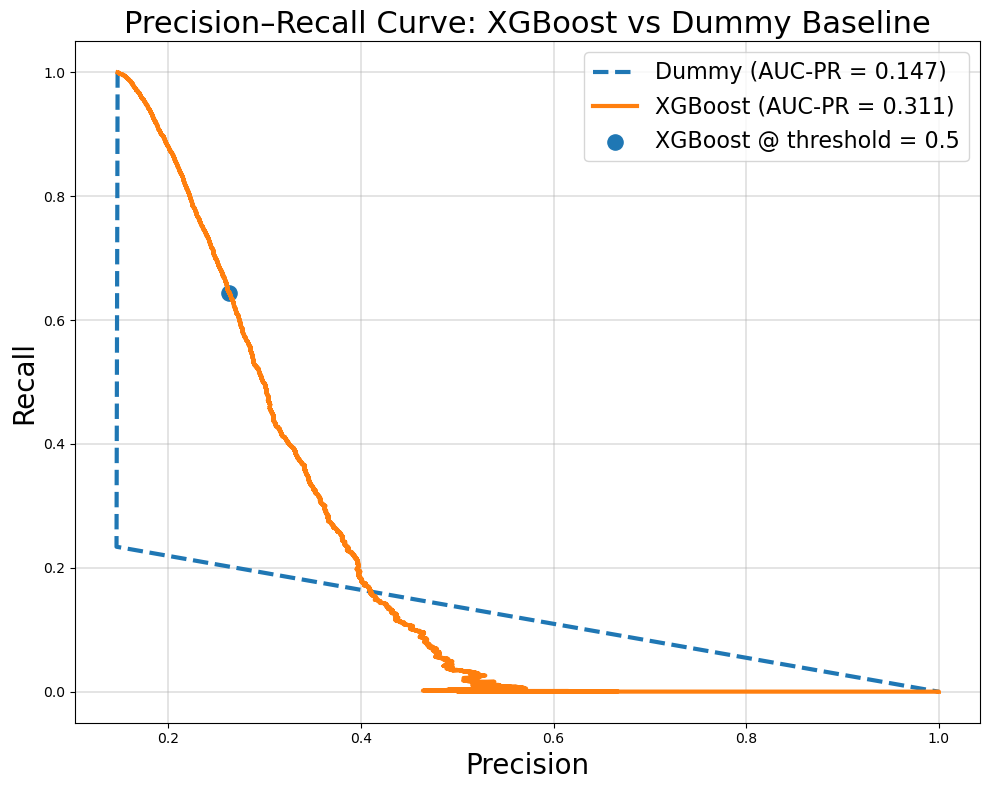

In [39]:
#PR Curve

plt.figure(figsize=(10, 8))

plt.plot(
    prec_dummy, rec_dummy,
    linestyle="--", linewidth=3,
    label=f"Dummy (AUC-PR = {auc_pr_dummy:.3f})"
)

plt.plot(
    prec_xgb, rec_xgb,
    linewidth=3,
    label=f"XGBoost (AUC-PR = {auc_pr_xgb:.3f})"
)

if len(thr_xgb) > 0:
    idx_05 = np.argmin(np.abs(thr_xgb - 0.5))
    plt.scatter(
        prec_xgb[idx_05], rec_xgb[idx_05],
        s=120,
        label="XGBoost @ threshold = 0.5"
    )

plt.xlabel("Precision", fontsize=20)
plt.ylabel("Recall", fontsize=20)
plt.title("Precision–Recall Curve: XGBoost vs Dummy Baseline", fontsize=22)
plt.legend(fontsize=16)
plt.grid(True, linewidth=1.2, alpha=0.4)

plt.tight_layout()
plt.savefig("../figures/XGBoost Analysis/PRcurve.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
#Global permutation importance

perm = permutation_importance(
    estimator=xgb_best,
    X=X_test_xgb_full,
    y=y_test,
    scoring=f2_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_test_xgb_full.columns,
    "mean_f2_drop": perm.importances_mean,
    "std_f2_drop": perm.importances_std
}).sort_values("mean_f2_drop", ascending=False)

In [ ]:

top_k = 20
top = perm_df.head(top_k).iloc[::-1]

plt.figure(figsize=(9, 7))
plt.barh(top["feature"], top["mean_f2_drop"], xerr=top["std_f2_drop"])
plt.xlabel("Mean decrease in Test F2 after permutation")
plt.title("Permutation Feature Importance (XGBoost)")
plt.tight_layout()
#plt.savefig("../figures/XGBoost Analysis/Permutation.png", dpi=300)
plt.show()

In [16]:
booster = xgb_best.get_booster()

In [ ]:
#XGBoost Gain
feature_names = list(xgb_feature_names_full)

raw_gain = booster.get_score(importance_type="gain") 

rows = []
for k, v in raw_gain.items():
    if k.startswith("f"):
        idx = int(k[1:])
        name = feature_names[idx] if idx < len(feature_names) else k
    else:
        name = k
    rows.append((name, v))

df_gain = (
    pd.DataFrame(rows, columns=["feature", "gain"])
      .sort_values("gain", ascending=False)
      .reset_index(drop=True)
)

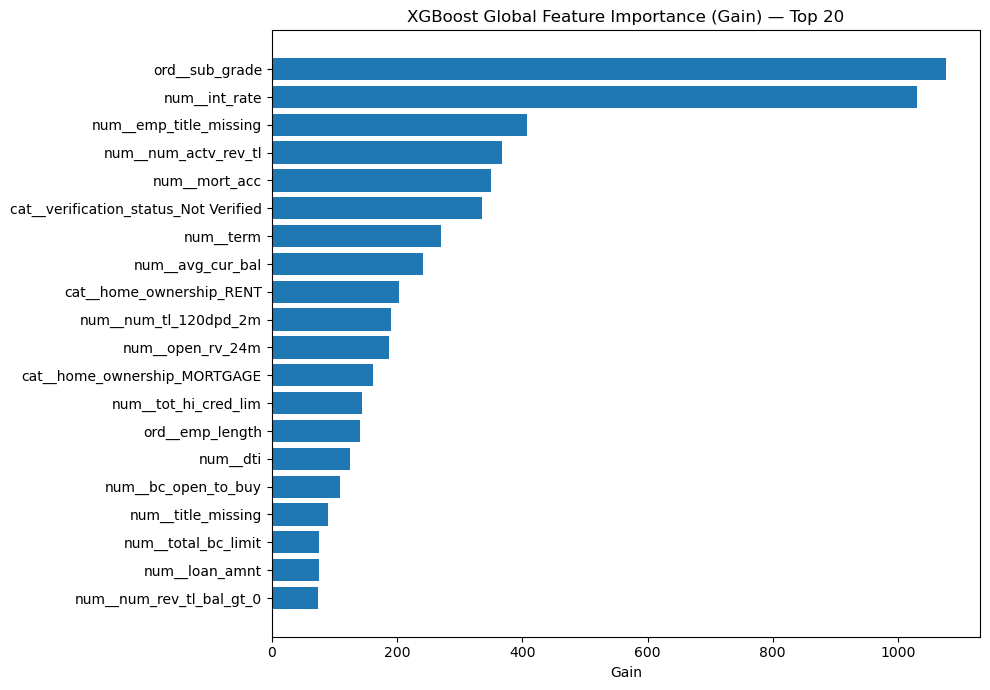

In [21]:
out_path = "../figures/XGBoost Analysis"

k = 20
top = df_gain.head(k).iloc[::-1] 

plt.figure(figsize=(10, 7))
plt.barh(top["feature"], top["gain"])
plt.xlabel("Gain")
plt.title(f"XGBoost Global Feature Importance (Gain) — Top {k}")
plt.tight_layout()

fig_path = os.path.join(out_path, "xgb_importance_gain_top20.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()



In [25]:
X_shap = X_test_xgb_full
y_shap = y_test

In [27]:
dtest = xgb.DMatrix(X_shap.values, feature_names=feature_names)

raw_contribs = booster.predict(dtest, pred_contribs=True)

# Split into feature SHAP + base value (bias term)
shap_vals = raw_contribs[:, :-1]   # (n_samples, n_features)
base_vals = raw_contribs[:, -1]    # (n_samples,)

print("SHAP matrix:", shap_vals.shape)

SHAP matrix: (47191, 1077)


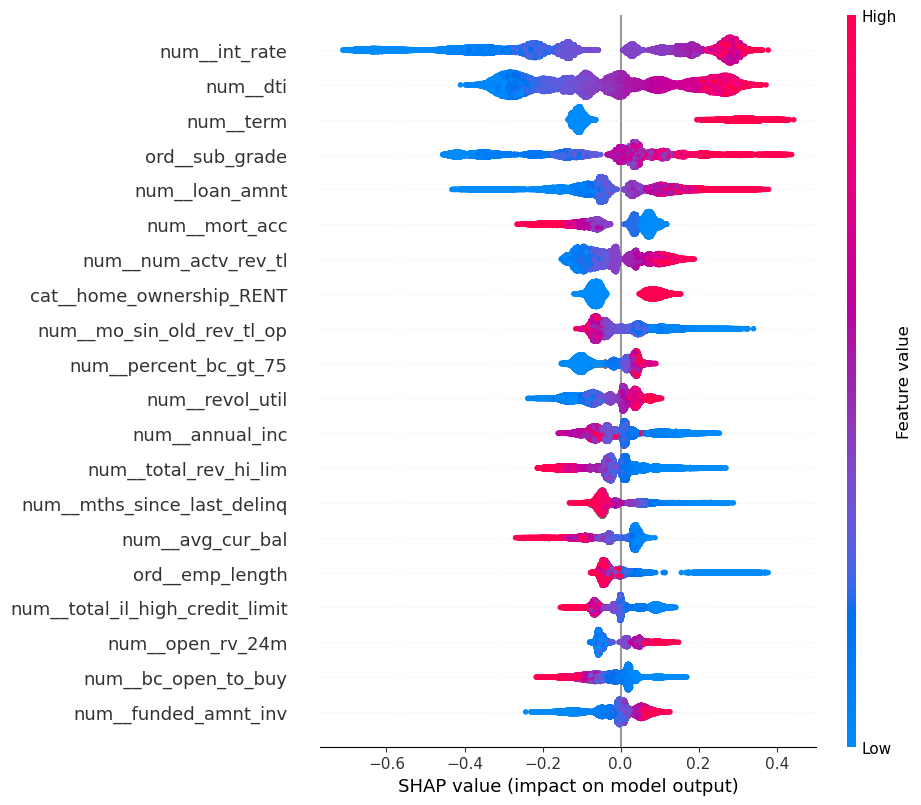

In [29]:
# Rank features by mean(|SHAP|)
mean_abs = np.abs(shap_vals).mean(axis=0)
topk = 20
top_idx = np.argsort(-mean_abs)[:topk]

shap_vals_top = shap_vals[:, top_idx]
data_top = X_shap.values[:, top_idx]
names_top = [feature_names[i] for i in top_idx]

expl_top = shap.Explanation(
    values=shap_vals_top,
    base_values=base_vals,
    data=data_top,
    feature_names=names_top,
)
plt.figure()
shap.plots.beeswarm(expl_top, max_display=topk, show=False)
fig_path = os.path.join(out_path, "xgb_shap_beeswarm_top20.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()



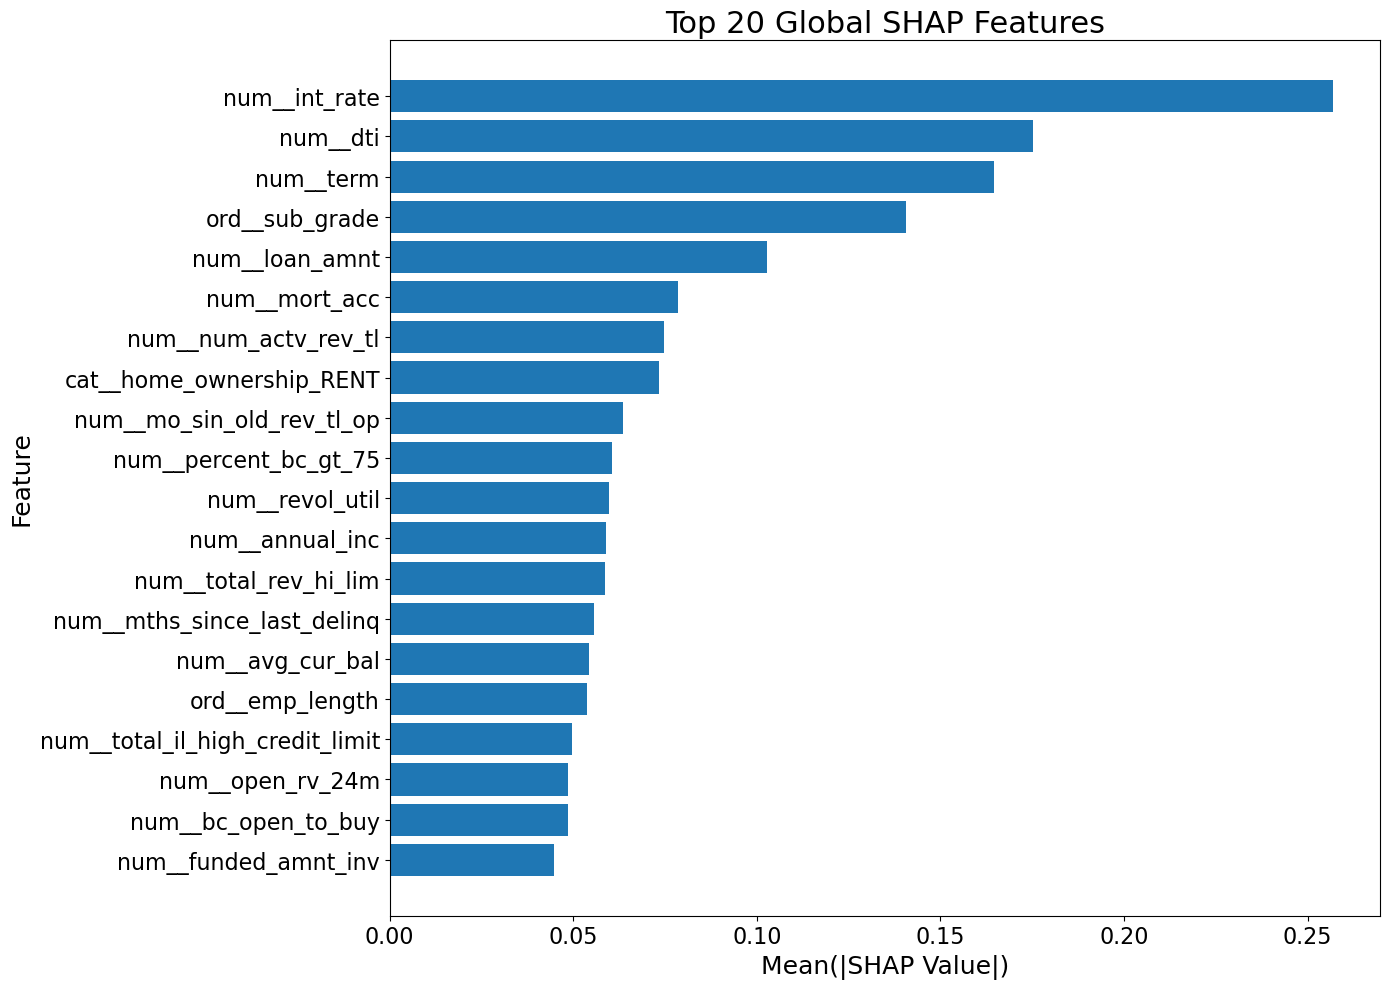

In [33]:
mean_abs = np.abs(shap_vals).mean(axis=0)
top20_idx = np.argsort(-mean_abs)[:20]

shap_vals_top20 = shap_vals[:, top20_idx]
feature_names_top20 = [feature_names[i] for i in top20_idx]
global_top20 = mean_abs[top20_idx]

# ===== Plot settings =====
plt.figure(figsize=(14, 10)) 
plt.barh(feature_names_top20, global_top20)

plt.xlabel("Mean(|SHAP Value|)", fontsize=18)
plt.ylabel("Feature", fontsize=18)
plt.title("Top 20 Global SHAP Features", fontsize=22)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.gca().invert_yaxis() 
plt.tight_layout()

fig_path = os.path.join(out_path, "shap_global_top20.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1800x400 with 0 Axes>

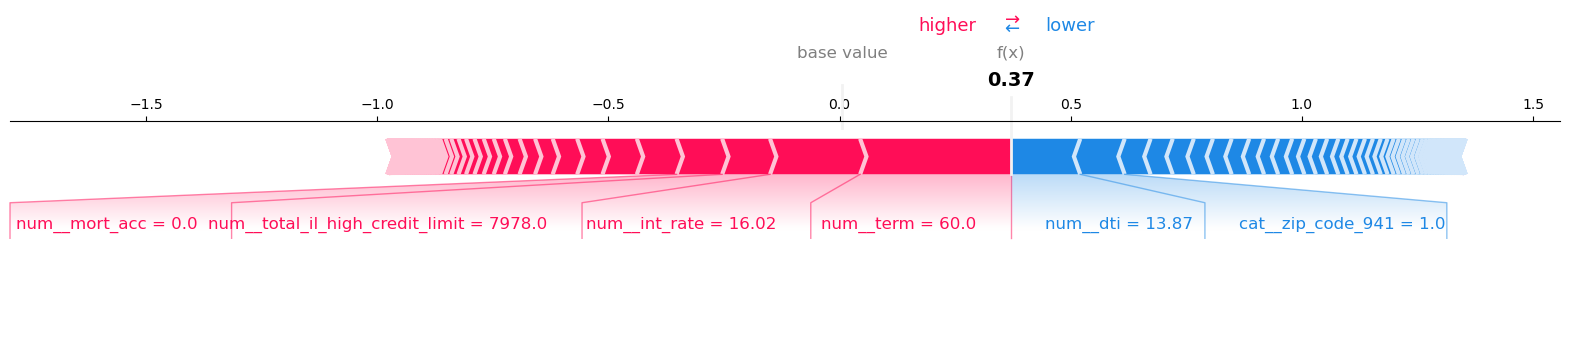

<Figure size 640x480 with 0 Axes>

<Figure size 1800x400 with 0 Axes>

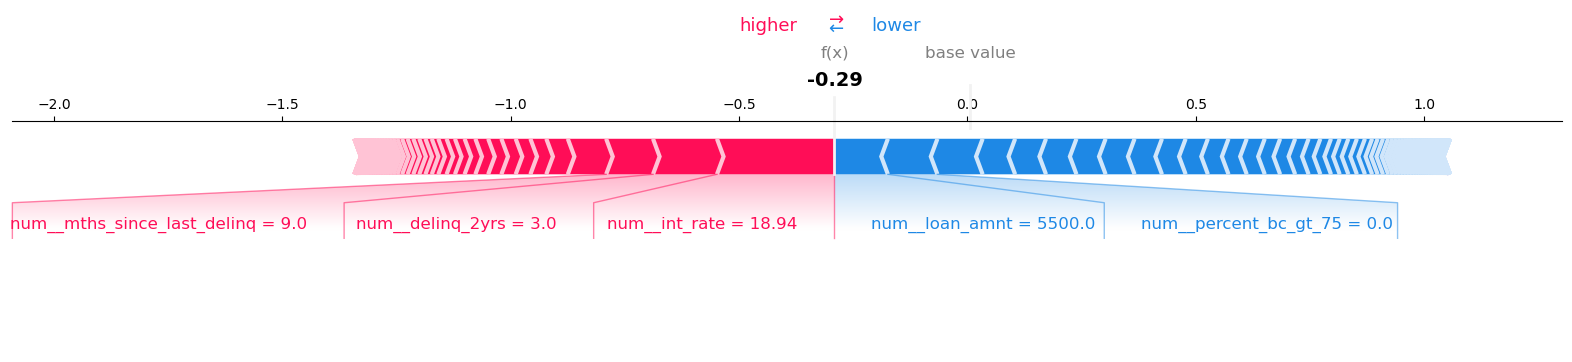

In [37]:
import os
import numpy as np
import matplotlib.pyplot as plt
import shap



df_indices = {
    "A": 433762,
    "B": 476834,
}

for label, df_idx in df_indices.items():
    pos = np.where(X_shap.index == df_idx)[0][0]

    plt.figure(figsize=(18, 4))
    shap.force_plot(
        base_value=base_vals[pos],
        shap_values=shap_vals[pos],
        features=X_shap.iloc[pos, :],
        feature_names=feature_names,
        matplotlib=True,
        show=False,
    )

    path = os.path.join(out_path, f"forceplot_{label}.png")
    plt.show()
    plt.savefig(path, dpi=350, bbox_inches="tight")

